# Khipus.ai — Estadística Aplicada con Python
## Módulo 2 · Clase 2 — Estadística Inferencial · **versión MINI**

**Docente:** Walter J. Méndez · UTEPSA / Khipus.ai
**Nombre:** _______________________________________

### La pregunta de hoy

> ## **¿Puedo confiar en lo que vi, o tuve suerte?**

La clase pasada describimos 538 anuncios de Airbnb. Sabíamos todo sobre **esos** 538, y cerramos con
una advertencia: **describir no es generalizar**.

Hoy damos el salto. Vamos a mirar una encuesta real a **1183 desarrolladores** y a aprender a
responder, con números y no con intuición: *lo que veo en mi muestra, ¿vale para todo el mundo, o es
pura casualidad?*

### Cómo usar este notebook

| Marca | Qué significa |
|---|---|
| 👨‍🏫 | Lo vemos juntos. La celda ya viene resuelta. |
| 🤔 | **Predecí antes de ejecutar** y escribí tu respuesta en el chat. |
| ✍️ | `TU TURNO`: lo completás vos. Hay pista. |
| ⏱️ | Minutos previstos para ese bloque. |

📌 Esta es la **versión mini**: lo esencial en 60 minutos (4 de arranque + 56 de bloques). El
notebook `02a_Estadistica_Inferencial_Practica_Guiada.ipynb` tiene la versión larga, con más
ejemplos, el caso Imanishi-Kari y el puente con Bayes, para estudiar con calma después.

In [31]:
import os                              # para ver si el archivo está en tu compu
import numpy as np                     # números y azar
import pandas as pd                    # tablas de datos
import matplotlib.pyplot as plt        # gráficos
import seaborn as sns                  # gráficos estadísticos, construido sobre matplotlib
from scipy import stats                # pruebas estadísticas

sns.set_style("whitegrid")             # fondo claro con grilla
# Buscamos el archivo local; si no está (por ejemplo en Colab), lo bajamos de internet.
_LOCAL = "../datos/data_dev.csv"
_URL = "https://raw.githubusercontent.com/Khipus-ai/Applied_Statistics_Python/main/3%20Inferential%20Statistics/data_dev.csv"
df = pd.read_csv(_LOCAL if os.path.exists(_LOCAL) else _URL)

print(f"Filas: {df.shape[0]}   Columnas: {df.shape[1]}")   # shape = (filas, columnas)
df.head()                              # las primeras 5 filas

Filas: 1183   Columnas: 24


,response_id,work_as_dev,age,employment,remote_work,coding_activities,ed_level,dev_type,years_code,years_code_pro,...,op_sys_professional_use,ai_view,ai_trust,ic_or_manager,work_exp,industry,us_or_not,plans_to_use_ai,converted_comp_yearly,survey_completion_date
0,164,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Engineer, data",14.0,10,...,Ubuntu;Windows,Very favorable,Somewhat trust,Individual contributor,10,"Information Services, IT, Software Development...",Not US,Using,3237,2023-05-02
1,165,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Data scientist or machine learning specialist,7.0,5,...,Ubuntu,Very favorable,Somewhat trust,Individual contributor,7,"Information Services, IT, Software Development...",Not US,Using,52046,2023-05-05
2,190,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Data scientist or machine learning specialist,8.0,8,...,Ubuntu;Windows,Favorable,Somewhat trust,Individual contributor,16,"Information Services, IT, Software Development...",Not US,Using,74963,2023-05-13
3,218,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Professional development or self-paced learnin...,Some college/university study without earning ...,Database administrator,29.0,17,...,Red Hat;Windows,Very favorable,Somewhat trust,Individual contributor,17,Wholesale,Not US,Plan to use,56757,2023-05-28
4,220,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Engineer, data",7.0,6,...,MacOS;Windows,Favorable,Somewhat trust,Individual contributor,7,NaN,Not US,Using,74963,2023-05-31


### La columna protagonista 👨‍🏫

`data_dev.csv` es el **Stack Overflow Developer Survey 2023**: respuestas reales de programadores de
todo el mundo. Hoy nos importan dos columnas:

- `converted_comp_yearly` → cuánto gana cada uno por año, en dólares.
- `plans_to_use_ai` → si **ya usa** inteligencia artificial en su trabajo o **piensa usarla**.

💡 Guardate esto: **las mayúsculas importan.** Al final de la clase vamos a volver sobre eso, y no de
la mejor manera.

In [32]:
df["plans_to_use_ai"].value_counts()   # cuenta cuántas filas hay de cada valor

plans_to_use_ai
Using          789
Plan to use    394
Name: count, dtype: int64

---
# Bloque 1 · El azar tiene forma  ⏱️ ~10 min

## ¿Qué es la probabilidad? 👨‍🏫

La probabilidad mide **qué tan esperable es un resultado**, en una escala de 0 (imposible) a 1
(seguro). Una moneda tiene 0.5 de sacar cara. Hasta acá, nada que no sepas.

Lo interesante no es una tirada. Es **qué pasa cuando repetís el experimento miles de veces**:
ahí aparecen unas formas que se repiten siempre, y son la base de todo lo que sigue.

In [33]:
np.random.seed(1)                      # semilla fija: a todos nos da lo mismo
tiradas = np.random.binomial(n=1, p=0.5, size=10000)   # 10.000 tiradas de moneda (1=cara, 0=sello)

print(f"Proporción de caras: {tiradas.mean():.4f}")
print("El valor teórico es 0.5. ¿Qué tan cerca quedamos?")

Proporción de caras: 0.5010
El valor teórico es 0.5. ¿Qué tan cerca quedamos?


## La distribución normal 👨‍🏫

Es la famosa **campana**. Aparece cuando algo es el resultado de sumar muchas causas chicas: la
altura de las personas, los errores de una balanza, los tiempos de reacción.

Se describe con dos números: dónde está el centro (**μ**, "mu") y qué tan ancha es (**σ**, "sigma").

💡 **Acá estrenamos `seaborn`**, la librería que la Clase 1 les prometió para "más adelante en el
módulo". Es matplotlib por debajo, pero dibuja histogramas más lindos y sabe agregarles la curva
suavizada encima (`kde=True`).

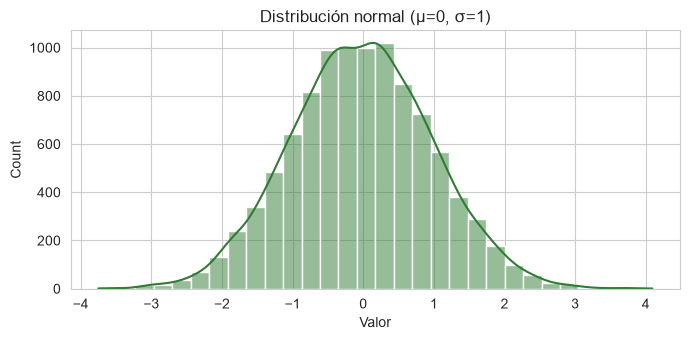

In [34]:
np.random.seed(3)
normal_sim = np.random.normal(loc=0, scale=1, size=10000)   # 10.000 valores: centro 0, ancho 1

plt.figure(figsize=(7, 3.5))
sns.histplot(normal_sim, bins=30, kde=True, color="#2E7D32")   # kde=True dibuja la curva encima
plt.title("Distribución normal (μ=0, σ=1)")
plt.xlabel("Valor")
plt.tight_layout()
plt.show()

## La distribución binomial 👨‍🏫

Es la de **contar éxitos en varios intentos**: cuántas caras en 10 tiradas, cuántos clientes compran
de 10 que entran, cuántos tests pasan de 10 que corrés.

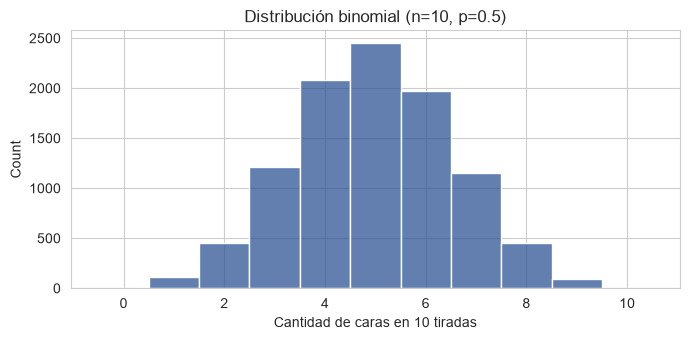

Promedio de caras: 4.97   (lo esperado es 10 × 0.5 = 5)


In [35]:
np.random.seed(2)
binom_sim = np.random.binomial(n=10, p=0.5, size=10000)   # 10.000 veces "tiro 10 monedas y cuento caras"

plt.figure(figsize=(7, 3.5))
sns.histplot(binom_sim, discrete=True, color="#2E5496")   # discrete=True: una barra por valor entero
plt.title("Distribución binomial (n=10, p=0.5)")
plt.xlabel("Cantidad de caras en 10 tiradas")
plt.tight_layout()
plt.show()

print(f"Promedio de caras: {binom_sim.mean():.2f}   (lo esperado es 10 × 0.5 = 5)")

### ✍️ TU TURNO 1

Simulá **20 tiradas** de una moneda **cargada**, con 70% de chance de cara, y contá cuántas caras
salieron.

💡 *Pista:* `np.random.binomial(n=1, p=0.7, size=20)` y después `.sum()`.

Número de caras en 20000 tiradas: 14000


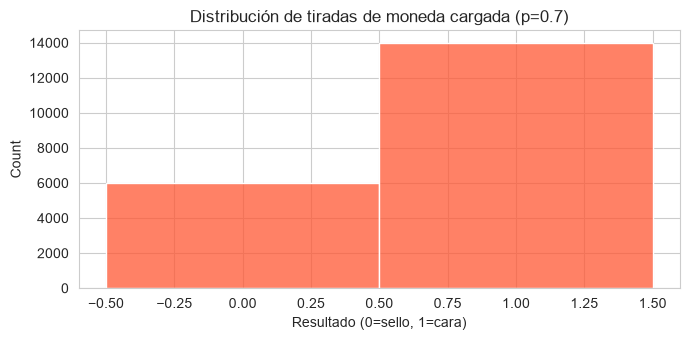

In [36]:
# TU TURNO 1: 20 tiradas de una moneda cargada (p=0.7), contar las caras
# Tu código aquí

np.random.seed(2)
tiradas_cargada = np.random.binomial(n=1, p=0.7, size=20000)
num_caras = tiradas_cargada.sum()
print(f"Número de caras en {tiradas_cargada.size} tiradas: {num_caras}")
plt.figure(figsize=(7, 3.5))
sns.histplot(tiradas_cargada, discrete=True, color="#FF5733")
plt.title("Distribución de tiradas de moneda cargada (p=0.7)")
plt.xlabel("Resultado (0=sello, 1=cara)")
plt.tight_layout()
plt.show()

⚠️ **Por qué esto importa hoy.** La clase pasada vimos que el precio de Airbnb **no** tenía forma de
campana. Y no era un capricho de ese archivo: **la mayoría de los datos reales no son normales.**

Pero casi toda la estadística clásica está construida sobre la campana. ¿Cómo se resuelve esa
contradicción? Es exactamente lo que vamos a ver ahora.

---
# Bloque 2 · Una sola muestra miente  ⏱️ ~6 min

## Los dos niveles 👨‍🏫

- **Población:** todos los programadores del mundo. Nunca la vamos a ver completa.
- **Muestra:** los 1183 que contestaron. Es lo único que tenemos.

💡 **La cuchara para probar la sopa.** Cuando cocinás para dos, probás la sal con una cucharita. El
domingo que vienen doce, la olla es seis veces más grande… y probás con **la misma cucharita**. El
tamaño de la muestra no crece en proporción a la población. Eso sí: si no revolvés la olla antes de
probar, no te salva una cuchara más grande.

In [73]:
np.random.seed(10)
muestra_chica = df["converted_comp_yearly"].sample(5)   # 5 personas al azar

print("Sueldos de 5 personas al azar:")
print(muestra_chica.to_string())
print(f"\nMedia de esta muestra:  ${muestra_chica.mean():,.0f}")
print(f"Media de las 1183:      ${df['converted_comp_yearly'].mean():,.0f}")

Sueldos de 5 personas al azar:
789      51403
188     107091
920      24045
1058    120000
936      80000

Media de esta muestra:  $76,508
Media de las 1183:      $90,684


### 🤔 Predicción

¿Si tomo **otra** muestra de 5 personas al azar, la media va a dar el mismo número? Escribí SÍ o NO
en el chat antes de ejecutar.

In [38]:
np.random.seed(99)                     # semilla distinta = otras 5 personas
otra_muestra = df["converted_comp_yearly"].sample(5)

print(f"Otra muestra de 5 → media:  ${otra_muestra.mean():,.0f}")
print(f"Media de las 1183:          ${df['converted_comp_yearly'].mean():,.0f}")

Otra muestra de 5 → media:  $100,567
Media de las 1183:          $90,684


---
# Bloque 3 · La distribución muestral, vista  ⏱️ ~8 min

👨‍🏫 Una muestra chica es un mal testigo: cada vez da otro número. Así que no vamos a mirar **una**
muestra. Vamos a mirar **mil**.

### 🤔 Predicción — la más importante del bloque

Vamos a tomar 1000 muestras de 5 personas, calcular la media de cada una, y graficar esas 1000
medias. Después lo mismo con muestras de 20.

**Antes de ejecutar:** ¿esas 1000 medias van a tener la misma forma torcida que los datos originales,
o va a cambiar? Y si cambia, ¿para dónde?

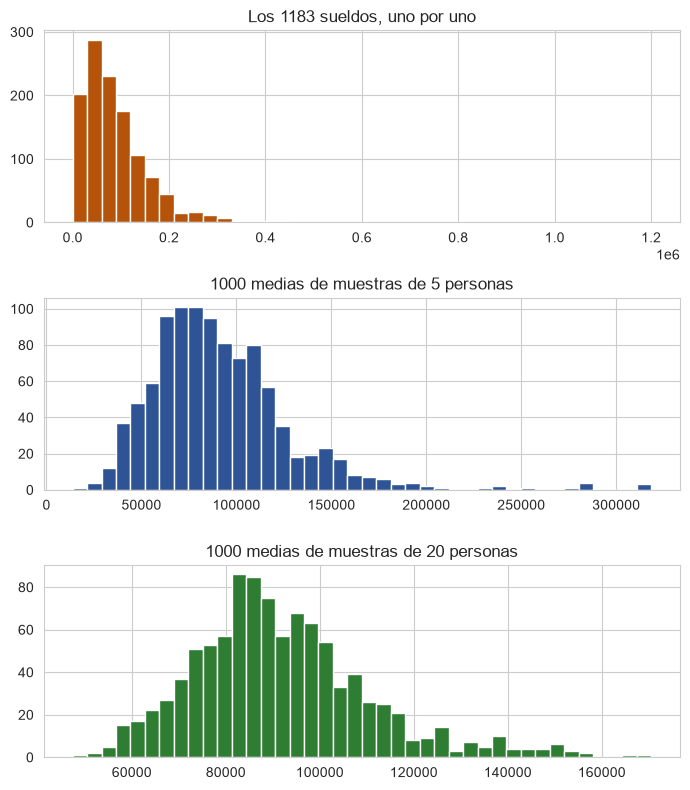

Torcimiento de los datos originales:   4.19
Torcimiento de las medias de 5:        1.81
Torcimiento de las medias de 20:       0.85


In [75]:
np.random.seed(7)
medias_de_5  = [df["converted_comp_yearly"].sample(5).mean()  for _ in range(1000)]
medias_de_20 = [df["converted_comp_yearly"].sample(20).mean() for _ in range(1000)]

plt.figure(figsize=(7, 8))

plt.subplot(3, 1, 1)                   # panel de arriba
plt.hist(df["converted_comp_yearly"], bins=40, color="#B45309", edgecolor="white")
plt.title("Los 1183 sueldos, uno por uno")

plt.subplot(3, 1, 2)                   # panel del medio
plt.hist(medias_de_5, bins=40, color="#2E5496", edgecolor="white")
plt.title("1000 medias de muestras de 5 personas")

plt.subplot(3, 1, 3)                   # panel de abajo
plt.hist(medias_de_20, bins=40, color="#2E7D32", edgecolor="white")
plt.title("1000 medias de muestras de 20 personas")

plt.tight_layout()
plt.show()

# skew mide qué tan torcida está una distribución. 0 = campana perfecta.
print(f"Torcimiento de los datos originales: {stats.skew(df['converted_comp_yearly']):6.2f}")
print(f"Torcimiento de las medias de 5:      {stats.skew(medias_de_5):6.2f}")
print(f"Torcimiento de las medias de 20:     {stats.skew(medias_de_20):6.2f}")

👨‍🏫 **Eso que acabás de ver es el Teorema del Límite Central.** Dice una sola cosa:

> No importa qué tan torcidos vengan los datos. La distribución de las **medias de muestras** se
> parece cada vez más a una campana a medida que la muestra crece.

Por eso la estadística clásica funciona aunque tus datos no sean normales: **no trabaja con tus
datos, trabaja con las medias.**

⚠️ **La trampa donde cae casi todo el mundo** (y está documentada en un estudio: Watkins,
Bargagliotti y Franklin, 2014). Es tentador concluir *"a medida que la muestra crece, la media se
acerca a la media real"*. **Es falso.** Lo único que cambia con el tamaño de la muestra es la
**forma** —se vuelve campana— y **el ancho**. El centro no se mueve: ya estaba en el lugar correcto
con muestras de 5.

### ✍️ TU TURNO 2

Repetí el experimento con muestras de **50** personas y mirá si el torcimiento sigue bajando.

💡 *Pista.* Esta vez usá la forma que vas a necesitar **en la tarea**:

```python
poblacion = df["converted_comp_yearly"].dropna().values   # lo pasa a un array de NumPy
muestra = np.random.choice(poblacion, 50)                 # 50 valores al azar
```

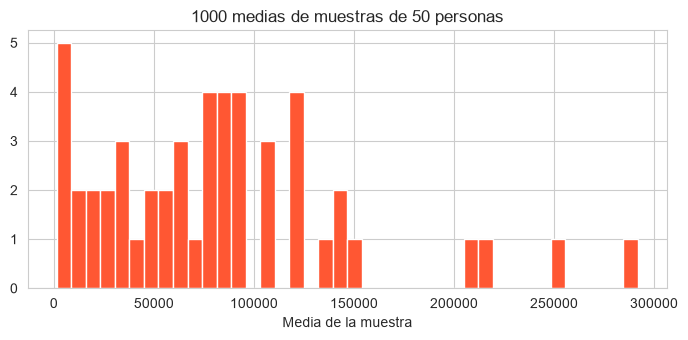

In [85]:
# TU TURNO 2: 1000 medias de muestras de 50, y su torcimiento
# Tu código aquí
np.random.seed(2)
#medias_muestras = [df["converted_comp_yearly"].sample(50).mean() for _ in range(1000)]
poblacion =df["converted_comp_yearly"].dropna().values
muestra = np.random.choice(poblacion, 50)  # Muestra aleatoria de 50 personas
plt.figure(figsize=(7, 3.5))
plt.hist(muestra, bins=40, color="#FF5733", edgecolor="white")
plt.title("1000 medias de muestras de 50 personas")
plt.xlabel("Media de la muestra")
plt.tight_layout()
plt.show()


---
# Bloque 4 · Del número suelto al rango honesto  ⏱️ ~8 min

## El bootstrap 👨‍🏫

Ya sabemos que la media "baila" de muestra en muestra. ¿Cuánto baila? A eso se le llama **error
estándar**, y para la media existe una fórmula. Pero, ¿y si querés el error estándar de la
**mediana**? No hay fórmula simple.

El **bootstrap** resuelve eso sin ninguna fórmula:

> Si no podés volver a encuestar al mundo, **volvé a sortear tu propia muestra**, miles de veces,
> permitiendo repetidos. Lo que varíen esos miles de resultados **es** tu error estándar.

In [41]:
np.random.seed(11)
medianas_boot = []
for _ in range(1000):                  # 1000 remuestreos
    remuestreo = df["converted_comp_yearly"].sample(frac=1, replace=True)   # mismo tamaño, con repetidos
    medianas_boot.append(remuestreo.median())
medianas_boot = pd.Series(medianas_boot)

print(f"Mediana real:                    ${df['converted_comp_yearly'].median():,.0f}")
print(f"Error estándar de la mediana:    ${medianas_boot.std():,.0f}")   # sin ninguna fórmula

Mediana real:                    $72,714
Error estándar de la mediana:    $2,252


## El intervalo de confianza 👨‍🏫

Decir *"la media es \$90.684"* sin más es una respuesta incompleta. Un **intervalo de confianza** es
un **rango** de valores plausibles. Con bootstrap se construye cortando las puntas del histograma.

Abajo hacemos como si tuviéramos **solo 20 personas** en vez de 1183, y vemos si el rango atrapa a la
media verdadera.

### 🤔 Predicción

Si en vez de 90% de confianza pedimos 99%, ¿el rango se hace **más angosto** o **más ancho**?

Con solo 20 personas, la media da: $89,282
IC 90%: [$68,813, $113,901]   ancho $45,088
IC 99%: [$59,703, $126,404]   ancho $66,701

La media real de los 1183 es $90,684. ¿Cayó adentro?


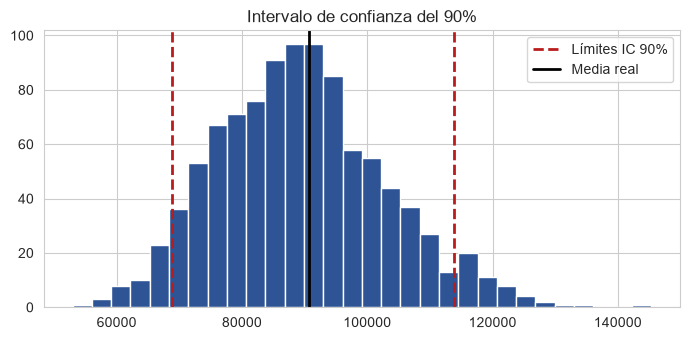

In [42]:
muestra_20 = df["converted_comp_yearly"].sample(20, random_state=3)   # nuestras "únicas" 20 personas

np.random.seed(3)
medias_boot = []
for _ in range(1000):                              # mismo patrón que el bootstrap de arriba
    medias_boot.append(muestra_20.sample(20, replace=True).mean())
medias_boot = pd.Series(medias_boot)               # a Series, para poder pedirle percentiles

ic_90 = medias_boot.quantile([0.05, 0.95])     # corta 5% de cada punta
ic_99 = medias_boot.quantile([0.005, 0.995])   # corta 0.5% de cada punta

print(f"Con solo 20 personas, la media da: ${muestra_20.mean():,.0f}")
print(f"IC 90%: [${ic_90.iloc[0]:,.0f}, ${ic_90.iloc[1]:,.0f}]   ancho ${ic_90.iloc[1]-ic_90.iloc[0]:,.0f}")
print(f"IC 99%: [${ic_99.iloc[0]:,.0f}, ${ic_99.iloc[1]:,.0f}]   ancho ${ic_99.iloc[1]-ic_99.iloc[0]:,.0f}")
print(f"\nLa media real de los 1183 es ${df['converted_comp_yearly'].mean():,.0f}. ¿Cayó adentro?")

plt.figure(figsize=(7, 3.5))
plt.hist(medias_boot, bins=30, color="#2E5496", edgecolor="white")
plt.axvline(ic_90.iloc[0], color="#B91C1C", linestyle="--", lw=2, label="Límites IC 90%")
plt.axvline(ic_90.iloc[1], color="#B91C1C", linestyle="--", lw=2)
plt.axvline(df["converted_comp_yearly"].mean(), color="black", lw=2, label="Media real")
plt.legend()
plt.title("Intervalo de confianza del 90%")
plt.tight_layout()
plt.show()

👨‍🏫 **Más confianza siempre cuesta un rango más ancho.** No hay forma de tener seguridad y
precisión gratis al mismo tiempo.

⚠️ **Y el bootstrap no es magia.** Repetimos este experimento completo 200 veces, con 200 muestras
distintas de 20 personas, y el intervalo del "90%" atrapó la media real **alrededor del 85% de las
veces, no el 90%**. Con muestras chicas se queda corto. Es una herramienta muy buena, no una
garantía.

---
# Bloque 5 · 🎬 ¿Los que usan IA ganan más?  ⏱️ ~10 min

Llegamos al momento central. Ya tenemos las herramientas: ahora respondemos una pregunta real.

In [43]:
usando = df.loc[df["plans_to_use_ai"] == "Using", "converted_comp_yearly"]        # ya usan IA
planea = df.loc[df["plans_to_use_ai"] == "Plan to use", "converted_comp_yearly"]  # piensan usarla

print(f"Ya usan IA     (n={len(usando)}):  media = ${usando.mean():,.0f}")
print(f"Planean usarla (n={len(planea)}):  media = ${planea.mean():,.0f}")
print(f"\nDiferencia observada: ${usando.mean() - planea.mean():,.0f}")

Ya usan IA     (n=789):  media = $92,088
Planean usarla (n=394):  media = $87,873

Diferencia observada: $4,215


### 🤔 Predicción — la más importante de la clase

Ahí está: los que ya usan IA ganan **más de \$4.000 más** por año, en promedio.

**Antes de seguir, escribí en el chat:** ¿creés que esa diferencia es **real** —o sea, que se
sostendría en todos los programadores del mundo— o puede ser pura casualidad de quiénes contestaron
la encuesta?

Pensalo como si tuvieras que decidir si esto se publica como noticia.

## La idea de la prueba de permutación 👨‍🏫

La pregunta exacta es: *si usar IA no tuviera **ningún** efecto sobre el sueldo, ¿cada cuánto
veríamos una diferencia tan grande solo por azar?*

Y se responde **sin ninguna fórmula**, jugando a las cartas:

1. Juntá los 1183 sueldos en **una sola bolsa**.
2. Repartilos **al azar** en dos montones, del mismo tamaño que los grupos reales.
3. Anotá la diferencia de medias de ese reparto trucho.
4. Repetilo 2000 veces.

Eso te da **todas las diferencias que el puro azar es capaz de producir**. Después mirás dónde cae
la tuya.

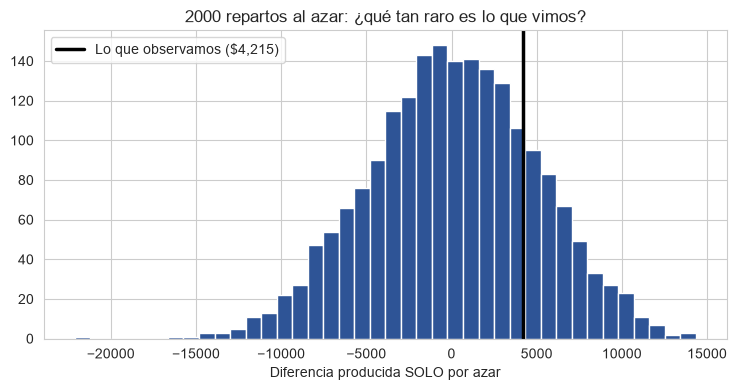

El azar solo ya produjo una diferencia igual o mayor en el 39.8% de los 2000 repartos.


In [44]:
# Reparte los sueldos en dos montones al azar y devuelve la diferencia de medias.
#   x   = todos los sueldos juntos (la "bolsa")
#   n_a = cuántos van al montón A   ·   n_b = cuántos van al montón B
def reparto_al_azar(x, n_a, n_b):
    n = n_a + n_b                                          # total de sueldos en la bolsa
    # OJO: acá np.random.choice recibe un NÚMERO (elige posiciones 0..n-1), no una lista.
    # Es la otra forma de usarla; en TU TURNO 2 la vas a usar sobre un array de valores.
    idx_a = set(np.random.choice(n, n_a, replace=False))   # posiciones que van al montón A
    idx_b = set(range(n)) - idx_a                          # todas las demás van al montón B
    return x.iloc[list(idx_a)].mean() - x.iloc[list(idx_b)].mean()   # la diferencia de este reparto

np.random.seed(42)
bolsa = pd.concat([usando, planea]).reset_index(drop=True)   # los 1183 sueldos, todos juntos
dif_observada = usando.mean() - planea.mean()                # la diferencia de verdad

dif_al_azar = np.array([reparto_al_azar(bolsa, len(usando), len(planea)) for _ in range(2000)])

plt.figure(figsize=(7.5, 4))
plt.hist(dif_al_azar, bins=40, color="#2E5496", edgecolor="white")
plt.axvline(dif_observada, color="black", lw=2.5, label=f"Lo que observamos (${dif_observada:,.0f})")
plt.legend()
plt.xlabel("Diferencia producida SOLO por azar")
plt.title("2000 repartos al azar: ¿qué tan raro es lo que vimos?")
plt.tight_layout()
plt.show()

p_permutacion = np.mean(np.abs(dif_al_azar) >= abs(dif_observada))
print(f"El azar solo ya produjo una diferencia igual o mayor en el {p_permutacion*100:.1f}% de los 2000 repartos.")

👨‍🏫 **Mirá bien ese gráfico, porque acabás de calcular un p-value sin saberlo.**

La línea negra es lo que pasó de verdad. El histograma es lo que produce el puro azar. El p-value es
simplemente **qué parte del histograma queda tan lejos o más lejos que la línea negra**. Nada más.

Y acá queda clarísimo: la línea negra cae **en plena montaña**, no en la orilla. Lo que observamos es
de lo más común que el azar puede producir.

---
# Bloque 6 · El p-value y el atajo de 1908  ⏱️ ~8 min

## Qué es y qué NO es 👨‍🏫

**Es:** la probabilidad de ver una diferencia como la tuya (o mayor) **suponiendo que no hay ningún
efecto real**.

⚠️ **Lo que NO es** — y esto no es opinión nuestra, es la declaración oficial de la American
Statistical Association (2016):

1. **NO** es la probabilidad de que "no haya efecto".
2. **NO** es la probabilidad de que el resultado se deba al azar.
3. Un p-value **no decide solo**. Ninguna conclusión seria se apoya en si un número quedó de un lado
   o del otro de 0.05.

💡 **Los binoculares.** Mirá dos perros de la misma raza con binoculares cada vez más potentes (más
datos): en algún momento vas a "ver" diferencias — un pelo, un bigote. Son reales, pero no los
convierte en **animales distintos**. Más datos siempre encuentran diferencias; si esas diferencias
**importan** es otra pregunta, y el p-value no la responde.

## El vocabulario que vas a encontrar afuera 👨‍🏫

| Lo que dijimos hoy | Cómo se llama formalmente |
|---|---|
| "supongamos que no hay efecto" | **Hipótesis nula**, **H₀** |
| "supongamos que sí lo hay" | **Hipótesis alternativa**, **H₁** |
| "el umbral de 0.05" | **Nivel de significancia**, **α** (alfa) |
| "dijimos que había efecto y no lo había" | **Error de Tipo I** (falso positivo) |
| "no vimos un efecto que sí existía" | **Error de Tipo II** (falso negativo) |

⚠️ Cuando el p-value sale grande se dice **"no rechazamos H₀"**, nunca *"aceptamos H₀"*. No encontrar
evidencia no es lo mismo que probar que no hay nada.

## El atajo de 1908 👨‍🏫

Todo lo del bloque anterior —repartir, contar, graficar— tiene un atajo matemático de **una línea**.
Se llama **t-test**, y lo inventó un empleado de la cervecería Guinness en 1908 que firmaba como
"Student" porque su empresa no lo dejaba publicar con su nombre.

El t-test devuelve **dos números**, y conviene saber qué es cada uno:

- **`t`** → *qué tan lejos está lo que viste, medido en unidades del ruido propio de los datos.*
  Un `t` cerca de 0 significa "esto es lo normal". Un `t` grande (para arriba o para abajo)
  significa "esto se sale de lo esperable". **El signo dice para qué lado.**
- **`p`** → el p-value que ya conocés: qué tan seguido el azar solo produce algo así.

In [45]:
t_stat, p_ttest = stats.ttest_ind(usando, planea, equal_var=False)   # compara DOS grupos entre sí

print(f"t-test:      t = {t_stat:.4f}   p = {p_ttest:.4f}")
print(f"Permutación:               p = {p_permutacion:.4f}")
print(f"\nDiferencia entre los dos métodos: {abs(p_ttest - p_permutacion):.4f}")

t-test:      t = 0.9293   p = 0.3529
Permutación:               p = 0.3975

Diferencia entre los dos métodos: 0.0446


👨‍🏫 **Casi el mismo número, en una línea en vez de diez.** Por eso el t-test se volvió el estándar:
antes de las computadoras nadie podía hacer 2000 repartos a mano.

Hoy la máquina los hace en un segundo — por eso arrancamos por ahí. Pero el t-test es lo que vas a
ver en el 90% de los programas y los informes, así que hay que saber leerlo.

⚠️ Ese `equal_var=False` significa *"no doy por sentado que los dos grupos varíen lo mismo"*. Es la
opción más prudente y la que conviene usar siempre por defecto. (Tiene nombre propio, **test de
Welch**, por si lo ves escrito así.)

## El otro t-test: una muestra contra un número de referencia 👨‍🏫

`ttest_ind` compara **dos grupos entre sí**. Pero muchas veces tenés **un solo grupo** y lo querés
comparar contra **un número que viene de afuera** (una meta, un informe del sector). Para eso está
`stats.ttest_1samp`, con dos parámetros que **la tarea te va a pedir**:

- `popmean=` → el número de referencia.
- `alternative=` → qué estás preguntando: `'greater'` (¿es mayor?), `'less'` (¿es menor?) o
  `'two-sided'` (¿es distinto?, y es **el valor por defecto**).

In [46]:
# ¿Los developers de esta encuesta ganan MÁS que los $85.000 de referencia?
t1, p1 = stats.ttest_1samp(df["converted_comp_yearly"], popmean=85000, alternative="greater")
print(f"Pregunta correcta ('¿ganan MÁS?'):        t = {t1:.4f}   p = {p1:.4f}")

# La MISMA línea, pero olvidándonos de escribir alternative:
t2, p2 = stats.ttest_1samp(df["converted_comp_yearly"], popmean=85000)
print(f"Sin alternative (queda 'two-sided'):      t = {t2:.4f}   p = {p2:.4f}")

print(f"\n¿El t es el mismo?              {t1 == t2}")
print(f"¿El p es exactamente el doble?  {abs(p2 - 2*p1) < 1e-12}")

Pregunta correcta ('¿ganan MÁS?'):        t = 2.3874   p = 0.0086
Sin alternative (queda 'two-sided'):      t = 2.3874   p = 0.0171

¿El t es el mismo?              True
¿El p es exactamente el doble?  True


💥 **Mirá bien lo que pasó: el `t` salió idéntico y el p-value se duplicó exacto.**

Acá los dos siguen siendo menores a 0.05, así que la conclusión aguanta. Pero basta con que el
número esté un poco más cerca del límite para que el mismo olvido **dé vuelta la conclusión
completa**. La celda de abajo lo muestra con \$86.500 en vez de \$85.000.

In [47]:
t3, p3 = stats.ttest_1samp(df["converted_comp_yearly"], popmean=86500, alternative="greater")
t4, p4 = stats.ttest_1samp(df["converted_comp_yearly"], popmean=86500)

print(f"Con alternative='greater':  t = {t3:.4f}   p = {p3:.4f}   → {'SIGNIFICATIVO' if p3 < 0.05 else 'no significativo'}")
print(f"Sin alternative:            t = {t4:.4f}   p = {p4:.4f}   → {'SIGNIFICATIVO' if p4 < 0.05 else 'no significativo'}")
print("\nMismo t. Conclusión opuesta. Y Python no te avisa de nada.")

Con alternative='greater':  t = 1.7574   p = 0.0396   → SIGNIFICATIVO
Sin alternative:            t = 1.7574   p = 0.0791   → no significativo

Mismo t. Conclusión opuesta. Y Python no te avisa de nada.


⚠️ **Esto te va a pasar en la tarea.** El `Assignment 2` pide explícitamente `alternative='less'` y
publica el resultado esperado. Si tu `t` coincide con el publicado pero tu p-value es **el doble**,
ya sabés exactamente qué te olvidaste de escribir.

### ✍️ TU TURNO 3

Dos partes:

1. Probá si estos sueldos son **menores** a \$95.000, usando `alternative='less'` — que es
   literalmente lo que pide la tarea.
2. Abajo del código, escribí **en un comentario y en una sola frase** qué significa ese resultado,
   como si se lo explicaras a tu jefe que nunca escuchó hablar de un p-value.

💡 *Pista:* misma línea de arriba, cambiando `popmean` y `alternative`. Para la frase, arrancá con
*"con estos datos, ..."*.

In [48]:
# TU TURNO 3: ¿la media es MENOR a 95.000? Usá alternative='less' + interpretá en una frase
# Tu código aquí



---
# Bloque 7 · El error que no hace ruido  ⏱️ ~6 min

En la Clase 1 tuvimos un error que **gritaba**: un `ValueError` bien ruidoso. Hoy vamos a ver uno
que **no dice absolutamente nada**.

Acordate: `plans_to_use_ai` vale `"Using"` o `"Plan to use"`, con mayúscula. ¿Qué pasa si escribimos
el filtro en minúscula, el typo más común del mundo?

### 🤔 Predicción

La celda de abajo, ¿va a tirar un error como el de la clase pasada, o va a "funcionar" sin quejarse?
Escribí SÍ (tira error) o NO (no tira error) en el chat.

In [49]:
grupo_con_typo = df.loc[df["plans_to_use_ai"] == "using", "converted_comp_yearly"]   # minúscula: el archivo dice "Using"

print(f"Filas encontradas: {len(grupo_con_typo)}")
print(f"Media calculada:   {grupo_con_typo.mean()}")   # promedio de cero filas

Filas encontradas: 0
Media calculada:   nan


💥 **No hubo ningún error.** El filtro no encontró ninguna fila, pandas no se quejó, y el promedio de
una tabla vacía es `nan`. En silencio. Si ese `nan` sigue viaje a un informe, nadie se entera.

👨‍🏫 **La lección no es "cuidado con las mayúsculas".** Es mucho más grande:

> **Que el código corra sin error NO significa que el resultado esté bien.**

💡 **La defensa, y la vas a usar toda tu carrera:** antes de filtrar por una columna de texto, mirá
sus valores con `.value_counts()` — como hicimos en la primera celda de hoy. Y desconfiá de cualquier
`nan` que aparezca donde esperabas un número.

---
## La respuesta a la pregunta de hoy 👨‍🏫

> ### **¿Puedo confiar en lo que vi, o tuve suerte?**

**Respuesta de alguien que solo sabe apretar `.mean()`:** *"los que usan IA ganan \$4.215 más"*.

**Respuesta profesional:** la diferencia existe en estos datos, pero un reparto puramente al azar
produce una diferencia igual o mayor en cerca del **40% de los casos**. Con esta muestra **no hay
evidencia** de que usar IA esté asociado a mejor sueldo. Podría ser cierto — pero estos datos no
alcanzan para probarlo.

Y un resultado así **no es un fracaso**: saber que no sabés es información real.

## Lo que dominás ahora

| Concepto | En Python | Para qué |
|---|---|---|
| Distribuciones | `np.random.normal`, `np.random.binomial` | Simular el azar |
| Distribución muestral | `.sample(n).mean()` repetido | Ver cuánto baila un promedio |
| Bootstrap | `.sample(frac=1, replace=True)` | Error estándar de lo que sea, sin fórmula |
| Intervalo de confianza | `.quantile([0.05, 0.95])` | Dar un rango en vez de un número |
| Permutación | repartir al azar y comparar | ¿La diferencia entre dos grupos es real? |
| t-test (2 grupos) | `stats.ttest_ind(a, b, equal_var=False)` | El atajo para comparar dos grupos |
| t-test (1 grupo) | `stats.ttest_1samp(x, popmean=, alternative=)` | Comparar contra un valor de referencia |

## Las 5 ideas que valen más que las funciones

1. Una sola muestra chica es un mal testigo.
2. El Teorema del Límite Central habla de la **forma** de las medias, no de que el centro se mueva.
3. Más confianza siempre cuesta un intervalo más ancho.
4. Un p-value mide compatibilidad con "no hay efecto". **No** es la probabilidad de que no lo haya.
5. Que el código no tire error no significa que esté bien. `.value_counts()` antes de filtrar texto.

## La tarea

**`Assignment 2` oficial de Khipus**, sobre `coffee_quality.csv`: las mismas dos ideas de hoy
(distribución muestral por remuestreo + prueba de una muestra) aplicadas a la calidad de cafés de
origen. Trae los resultados esperados publicados, así que **te autoverificás solo**.

⚠️ Recordá el Bloque 6 de este notebook: el Task 2 pide `alternative='less'`. Si tu `t` coincide con
el publicado y tu p-value es el doble, ya sabés qué falta.

💡 **Antes de calcular nada**, aplicá el método de la Clase 1: `head()`, `info()`, buscar nulos y
duplicados.

📌 El **Task 1** de la tarea es, casi letra por letra, el TU TURNO 2 de hoy:
`np.random.seed(2025)`, `np.random.choice`, muestras de 50, mil repeticiones.

## 📌 Para después de clase

- El **caso Imanishi-Kari** (fraude científico detectado con chi-cuadrado) y la **falacia del
  fiscal** en el caso Sally Clark están en el notebook largo,
  `02a_Estadistica_Inferencial_Practica_Guiada.ipynb`.
- Ese mismo notebook trae los bloques de hoy con más ejemplos y más detalle.